<a href="https://colab.research.google.com/github/0xjessie21/data-science-2026/blob/main/Pertemuan6_MOHAMMAD_RIYAN_SYAIFUNAHAR_240401010292.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 6 — Persiapan Data
**Nama:** MOHAMMAD RIYAN SYAIFUNAHAR  
**NIM:** 240401010292  
**Mata Kuliah:** Pengantar Data Science  
**Dataset:** Titanic (891 baris, 8 kolom terpilih)

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder,
    OrdinalEncoder, StandardScaler,
    MinMaxScaler, RobustScaler
)
from sklearn.model_selection import train_test_split

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Langkah 1 — Load & EDA Singkat

In [2]:
df_raw = sns.load_dataset('titanic')

cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df_raw[cols].copy()

print('Shape:', df.shape)
print('\nTipe data per kolom:')
print(df.dtypes)

Shape: (891, 8)

Tipe data per kolom:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object


In [3]:
print('5 Baris Pertama:')
df.head()

5 Baris Pertama:


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [4]:
missing    = df.isnull().sum()
persen     = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': persen})

print('=== Missing Values per Kolom ===')
print(missing_df[missing_df['Jumlah Missing'] > 0])

=== Missing Values per Kolom ===
          Jumlah Missing  Persentase (%)
age                  177           19.87
embarked               2            0.22


In [5]:
print('=== Distribusi Target (survived) ===')
print(df['survived'].value_counts())
print()
print(df['survived'].value_counts(normalize=True).round(3))

=== Distribusi Target (survived) ===
survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [6]:
print('=== Statistik Deskriptif ===')
df.describe().round(2)

=== Statistik Deskriptif ===


,pclass,age,sibsp,parch,fare,survived
count,891.00,714.00,891.00,891.00,891.00,891.00
mean,2.31,29.70,0.52,0.38,32.20,0.38
std,0.84,14.53,1.10,0.81,49.69,0.49
min,1.00,0.42,0.00,0.00,0.00,0.00
25%,2.00,20.12,0.00,0.00,7.91,0.00
50%,3.00,28.00,0.00,0.00,14.45,0.00
75%,3.00,38.00,1.00,0.00,31.00,1.00
max,3.00,80.00,8.00,6.00,512.33,1.00


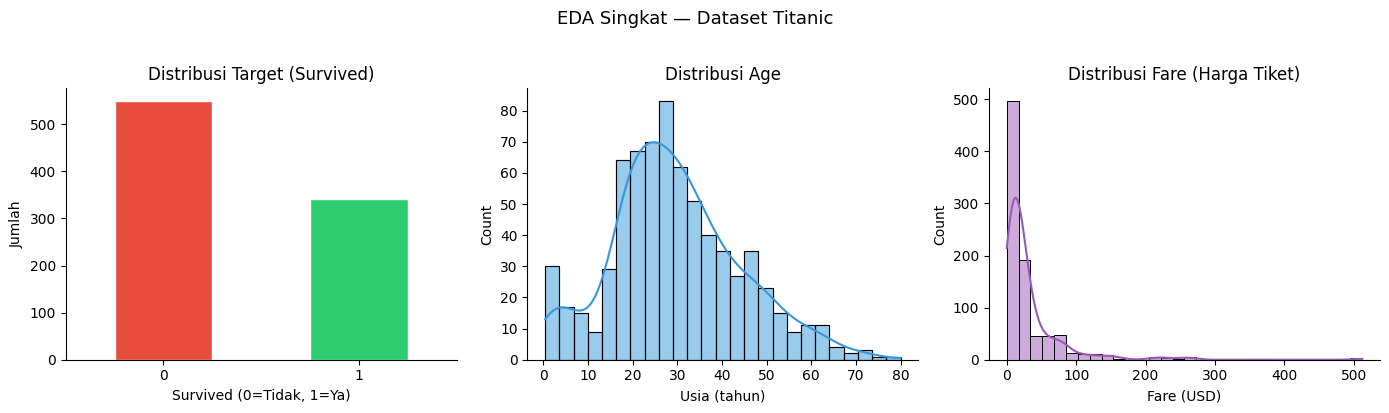

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['survived'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'],
    edgecolor='white'
)
axes[0].set_title('Distribusi Target (Survived)')
axes[0].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines[['top', 'right']].set_visible(False)

sns.histplot(df['age'].dropna(), bins=25, color='#3498DB',
             kde=True, ax=axes[1])
axes[1].set_title('Distribusi Age')
axes[1].set_xlabel('Usia (tahun)')
axes[1].spines[['top', 'right']].set_visible(False)

sns.histplot(df['fare'], bins=30, color='#9B59B6',
             kde=True, ax=axes[2])
axes[2].set_title('Distribusi Fare (Harga Tiket)')
axes[2].set_xlabel('Fare (USD)')
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('EDA Singkat — Dataset Titanic', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Temuan Langkah 1:**  
- Dataset memiliki **891 baris** dan **8 kolom** terpilih  
- Missing values: `age` (177 baris = 19.87%), `embarked` (2 baris = 0.22%)  
- Target tidak seimbang: 61.6% tidak selamat vs 38.4% selamat → perlu `stratify=y` saat split  
- Distribusi `fare` sangat right-skewed → cocok menggunakan `StandardScaler` atau `RobustScaler`

---
## Langkah 2 — Handling Missing Values

In [8]:
print('Missing SEBELUM handling:')
print(df.isnull().sum())

Missing SEBELUM handling:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64


In [9]:
median_age = df['age'].median()
df['age']  = df['age'].fillna(median_age)
print(f'Median age digunakan untuk imputasi: {median_age}')

modus_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(modus_embarked)
print(f'Modus embarked digunakan untuk imputasi: {modus_embarked}')

print('\nMissing SETELAH handling:')
print(df.isnull().sum())

Median age digunakan untuk imputasi: 28.0
Modus embarked digunakan untuk imputasi: S

Missing SETELAH handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


**Temuan Langkah 2:**  
- `age`: diisi dengan **median = 28.0** — dipilih karena distribusi age sedikit right-skewed, median lebih robust dari mean  
- `embarked`: diisi dengan **modus = 'S'** (Southampton) — nilai yang paling sering muncul  
- Setelah handling, **0 missing values** di seluruh kolom

---
## Langkah 3 — Encoding Kategorikal

In [10]:
print('Kolom SEBELUM encoding:')
print(df.columns.tolist())
print()
print('Nilai unik sex     :', df['sex'].unique())
print('Nilai unik embarked:', df['embarked'].unique())

Kolom SEBELUM encoding:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']

Nilai unik sex     : ['male' 'female']
Nilai unik embarked: ['S' 'C' 'Q']


In [11]:
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int
)

print('Kolom SETELAH encoding:')
print(df.columns.tolist())

Kolom SETELAH encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


In [12]:
print('Contoh 5 baris setelah encoding:')
df.head()

Contoh 5 baris setelah encoding:


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


**Temuan Langkah 3:**  
- Kolom `sex` (male/female) → **sex_male** (1=pria, 0=wanita) — `drop_first=True` menghilangkan kolom redundan `sex_female`  
- Kolom `embarked` (C/Q/S) → **embarked_Q** dan **embarked_S** — kolom `embarked_C` dihapus untuk menghindari multikolinearitas  
- Total kolom bertambah dari 8 menjadi **9 kolom** (3 kolom baru OHE, 2 kolom lama dihapus)

---
## Langkah 4 — Train-Test Split

In [13]:
X = df.drop('survived', axis=1)
y = df['survived']

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('\nKolom fitur X:')
print(X.columns.tolist())

Shape X: (891, 8)
Shape y: (891,)

Kolom fitur X:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% untuk test
    random_state=42,     # reproduktibel
    stratify=y           # proporsi kelas terjaga
)

print(f'Train: {X_train.shape[0]} baris  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test : {X_test.shape[0]} baris  ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 712 baris  (79.9%)
Test : 179 baris  (20.1%)


In [15]:
print('Proporsi survived di TRAIN:')
print(y_train.value_counts(normalize=True).round(3))

print('\nProporsi survived di TEST:')
print(y_test.value_counts(normalize=True).round(3))

Proporsi survived di TRAIN:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di TEST:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


**Temuan Langkah 4:**  
- Dataset dibagi **80:20** → 712 baris training, 179 baris test  
- Berkat `stratify=y`, proporsi kelas di train dan test **hampir identik** (~61.6% tidak selamat, ~38.4% selamat)  
- `random_state=42` memastikan hasil split **selalu sama** setiap kali dijalankan (reproduktibel)  
- Split dilakukan **sebelum scaling** untuk mencegah data leakage

---
## Langkah 5 — Feature Scaling

In [16]:
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']

print('Kolom numerik yang akan di-scale:')
print(num_cols)

print('\nStatistik SEBELUM scaling (X_train):')
print(X_train[num_cols].describe().round(3))

Kolom numerik yang akan di-scale:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Statistik SEBELUM scaling (X_train):
        pclass      age    sibsp    parch     fare
count  712.000  712.000  712.000  712.000  712.000
mean     2.309   29.460    0.493    0.390   31.820
std      0.834   13.035    1.061    0.838   48.059
min      1.000    0.420    0.000    0.000    0.000
25%      2.000   22.000    0.000    0.000    7.896
50%      3.000   28.000    0.000    0.000   14.454
75%      3.000   36.000    1.000    0.000   31.000
max      3.000   80.000    8.000    6.000  512.329


In [17]:
X_train = X_train.copy()
X_test  = X_test.copy()

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train) :', scaler.mean_.round(3))
print('Std scaler  (dari train) :', scaler.scale_.round(3))

Mean scaler (dari train) : [ 2.309 29.46   0.493  0.39  31.82 ]
Std scaler  (dari train) : [ 0.833 13.025  1.06   0.838 48.025]


In [18]:
print('Statistik SETELAH scaling (X_train):')
print(X_train[num_cols].describe().round(3))

Statistik SETELAH scaling (X_train):
        pclass      age    sibsp    parch     fare
count  712.000  712.000  712.000  712.000  712.000
mean    -0.000    0.000   -0.000   -0.000   -0.000
std      1.001    1.001    1.001    1.001    1.001
min     -1.571   -2.229   -0.465   -0.466   -0.663
25%     -0.371   -0.573   -0.465   -0.466   -0.498
50%      0.830   -0.112   -0.465   -0.466   -0.362
75%      0.830    0.502    0.478   -0.466   -0.017
max      0.830    3.880    7.082    6.698   10.005


In [19]:
print('Contoh X_train setelah scaling (3 baris pertama):')
print(X_train.head(3).round(3))

Contoh X_train setelah scaling (3 baris pertama):
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1


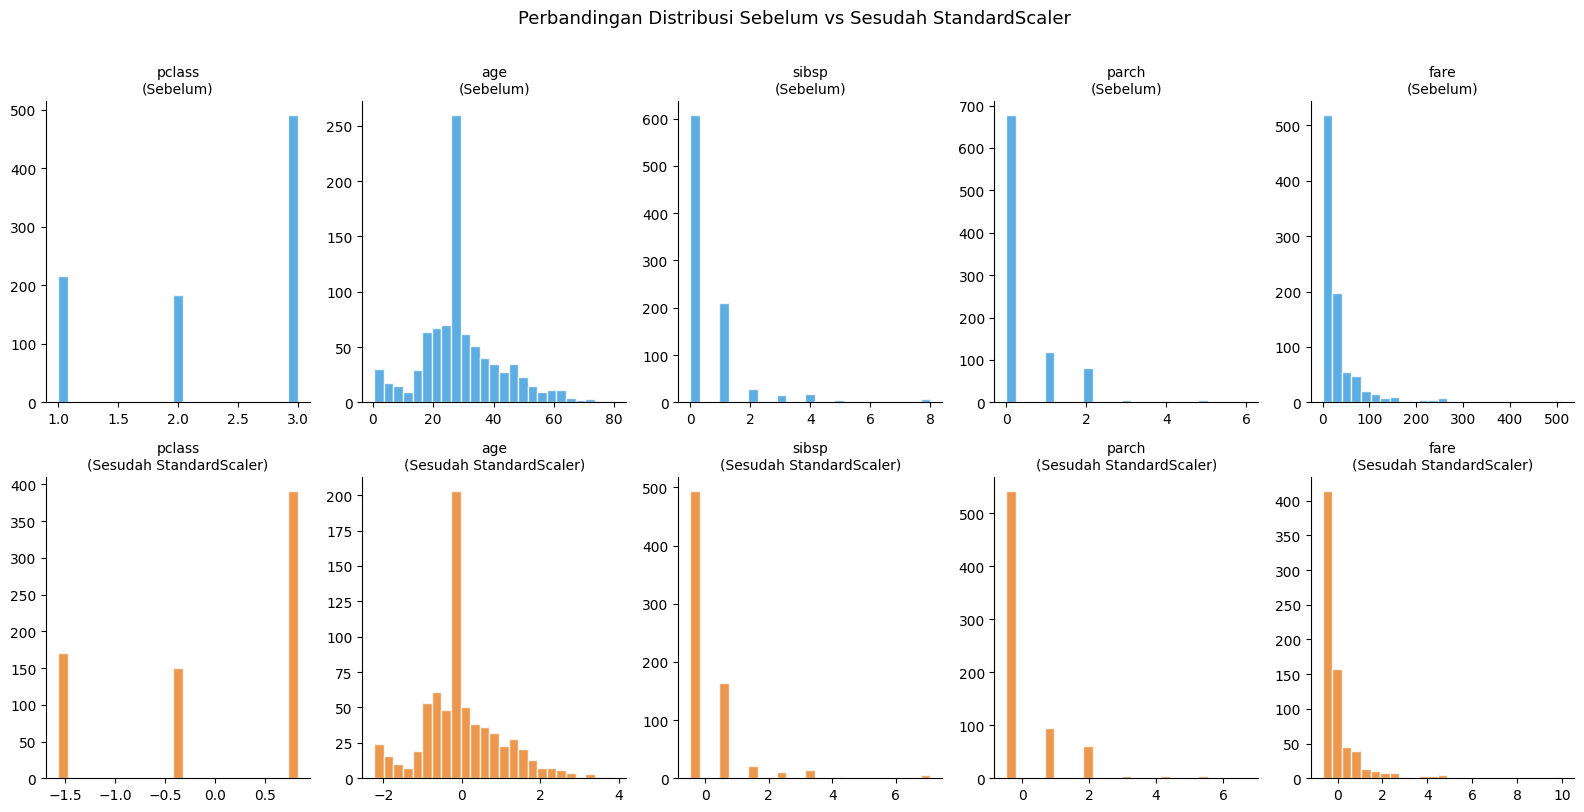

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))

X_before = df.drop('survived', axis=1)

for i, col in enumerate(num_cols):
    # Sebelum scaling
    axes[0, i].hist(X_before[col], bins=25, color='#3498DB',
                    edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Sebelum)', fontsize=10)
    axes[0, i].spines[['top', 'right']].set_visible(False)

    # Sesudah scaling
    axes[1, i].hist(X_train[col], bins=25, color='#E67E22',
                    edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(Sesudah StandardScaler)', fontsize=10)
    axes[1, i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Perbandingan Distribusi Sebelum vs Sesudah StandardScaler',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Temuan Langkah 5:**  
- `StandardScaler` di-**fit hanya pada X_train** → μ dan σ dipelajari dari training data saja  
- X_test di-**transform** (bukan fit_transform) menggunakan parameter dari training → mencegah **data leakage**  
- Setelah scaling, semua kolom numerik memiliki **mean ≈ 0** dan **std ≈ 1**  
- Bentuk distribusi tidak berubah — hanya skala yang bergeser, bukan urutan atau pola data  
- Kolom biner OHE (`sex_male`, `embarked_Q`, `embarked_S`) **tidak di-scale** karena sudah dalam rentang [0,1]

---
## Langkah 6 — Validasi Akhir Pipeline

In [21]:
print('=' * 50)
print('RINGKASAN PIPELINE PREPROCESSING')
print('=' * 50)
print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')
print()
print(f'Missing values X_train: {X_train.isnull().sum().sum()}')
print(f'Missing values X_test : {X_test.isnull().sum().sum()}')
print()
print('Kolom fitur final:')
print(X_train.columns.tolist())
print()
print('Data siap dilatih model Machine Learning!')

RINGKASAN PIPELINE PREPROCESSING
X_train shape : (712, 8)
X_test  shape : (179, 8)
y_train shape : (712,)
y_test  shape : (179,)

Missing values X_train: 0
Missing values X_test : 0

Kolom fitur final:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']

Data siap dilatih model Machine Learning!


In [22]:
print('=== Perbandingan 3 Scaler pada kolom fare ===')

fare_train = X_before.loc[X_train.index, 'fare'].values.reshape(-1, 1)

scalers = {
    'MinMaxScaler'   : MinMaxScaler(),
    'StandardScaler' : StandardScaler(),
    'RobustScaler'   : RobustScaler()
}

for name, sc in scalers.items():
    hasil = sc.fit_transform(fare_train)
    print(f'{name:18s} → min={hasil.min():.3f}, max={hasil.max():.3f}, '
          f'mean={hasil.mean():.3f}, std={hasil.std():.3f}')

=== Perbandingan 3 Scaler pada kolom fare ===
MinMaxScaler       → min=0.000, max=1.000, mean=0.062, std=0.094
StandardScaler     → min=-0.663, max=10.005, mean=-0.000, std=1.000
RobustScaler       → min=-0.626, max=21.549, mean=0.752, std=2.079


---
## Ringkasan Pipeline End-to-End

| Langkah | Aksi | Detail |
|---------|------|--------|
| 1 | Load & EDA | 891 baris, missing: age(177), embarked(2), target tidak seimbang |
| 2 | Handling Missing | age → median (28.0), embarked → modus ('S') |
| 3 | Encoding | sex & embarked → One-Hot Encoding (drop_first=True) |
| 4 | Train-Test Split | 80:20, stratify=y, random_state=42 → 712 train / 179 test |
| 5 | Feature Scaling | StandardScaler fit pada X_train, transform X_test (anti-leakage) |
| 6 | Validasi | 0 missing, shape benar, data siap masuk model ML |

**Aturan Penting yang Diterapkan:**
- ✅ Missing values ditangani **sebelum** encoding  
- ✅ Train-Test Split dilakukan **sebelum** scaling  
- ✅ Scaler di-**fit hanya pada X_train**, X_test hanya di-transform  
- ✅ Kolom biner OHE **tidak di-scale**  
- ✅ `stratify=y` digunakan karena kelas target tidak seimbang